This code was created on Aug 7th, the code runs after 01_preprocessing.ipynb. 


In [26]:
import os
print("Working dir is now:", os.getcwd())

DATA_PATH = "/Users/adrian/Documents/01_projects/14_4D_lab/data"
OUTPUT_PATH = "/Users/adrian/Documents/01_projects/14_4D_lab/output/02_gnm_estimation"

PREPROCESSED_PATH = DATA_PATH + "/preprocessed/01_first_analysises"


# create output path if it does not exist
if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

if not os.path.exists(PREPROCESSED_PATH):
    os.makedirs(PREPROCESSED_PATH)

Working dir is now: /Users/adrian/Documents/01_projects/14_4D_lab


In [27]:
import numpy as np
import scipy.io
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

In [32]:
connectomes_binarized = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/connectomes_binarized.npy")
consensus_connectome_bin = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/consensus_connectome_bin.npy")

dist_mat = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/distance_matrix.npy")
df_identifiers = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/df_identifiers.csv") 
all_connectomes = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/all_connectomes.npy")
# df_graph_measures_bin = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/df_graph_measures_bin.csv")
df_graph_measures_all = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/df_graph_measures_all.csv")
df_graph_measures = df_graph_measures_all

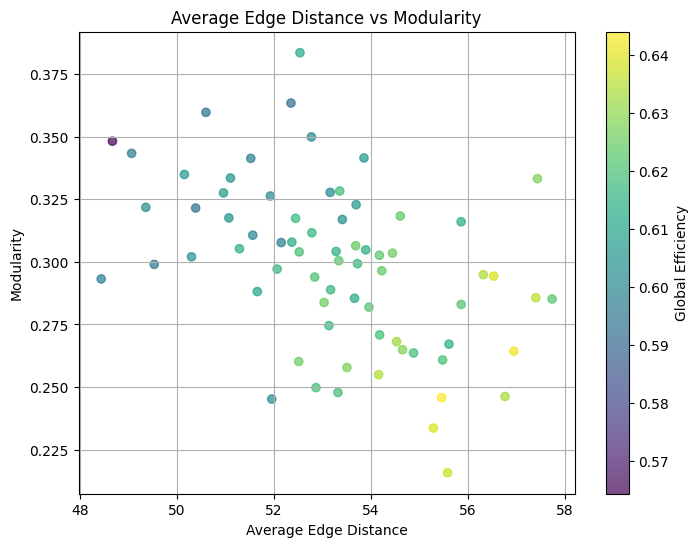

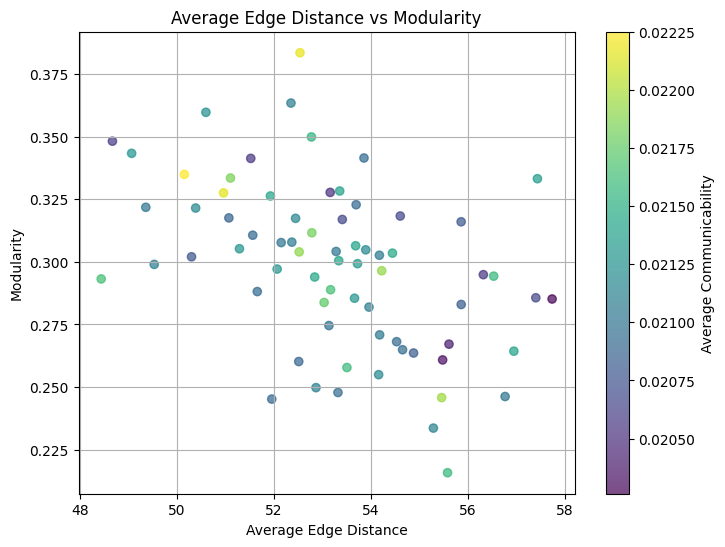

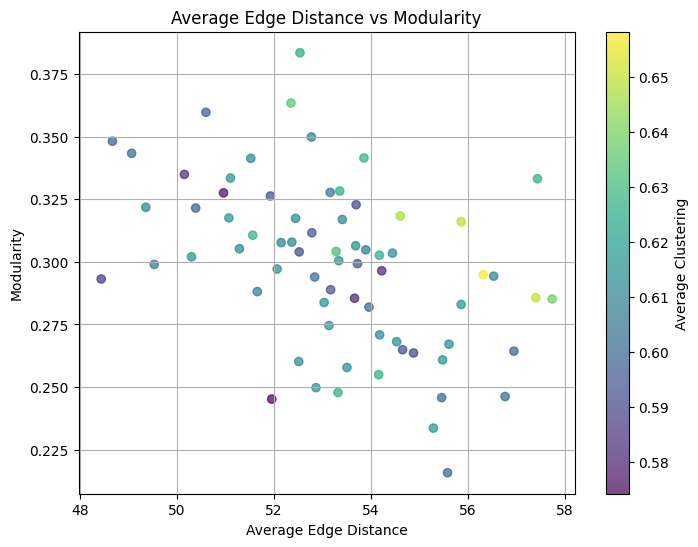

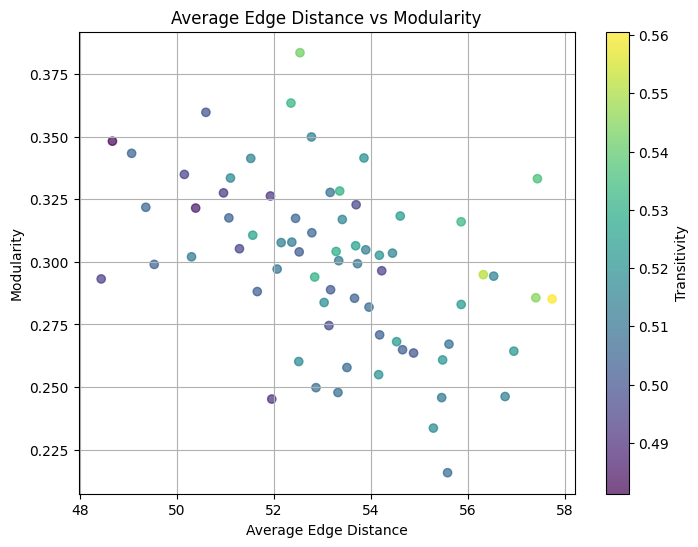

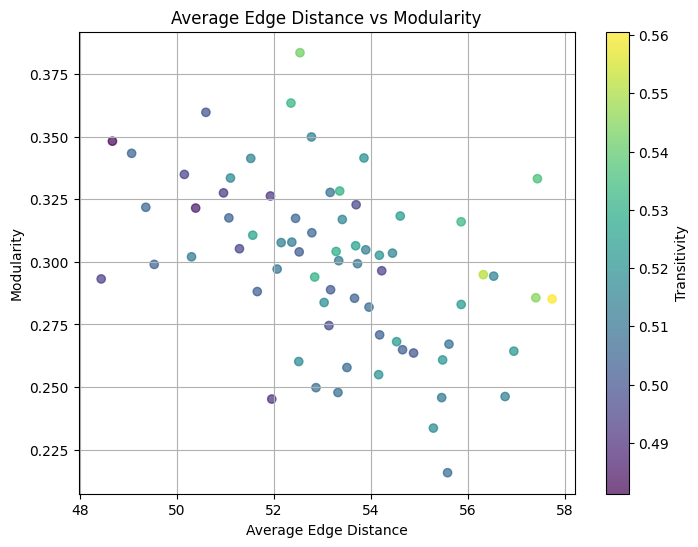

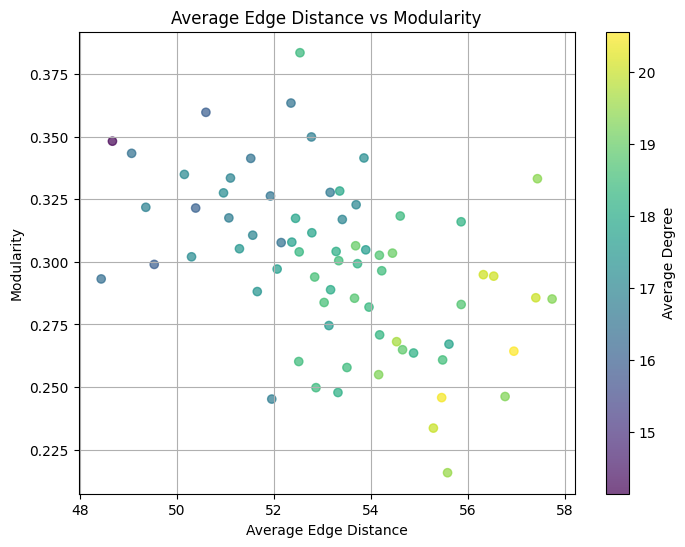

In [29]:
# 2D scatterplots

df = df_graph_measures # df_graph_measures_all # graph_measures_df
# plt.figure(figsize=(6, 6))
# plt.scatter(df['avg_communicability'], df['global_efficiency'], alpha=0.7)
# plt.title('Average Communicability vs Global Efficiency')
# plt.xlabel('Average Communicability')
# plt.ylabel('Global Efficiency')
# plt.grid(True)
# plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['global_efficiency'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Global Efficiency')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['avg_communicability'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Average Communicability')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['avg_clustering'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Average Clustering')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['transitivity'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Transitivity')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['transitivity'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Transitivity')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['avg_degree'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Average Degree')
plt.grid(True)
plt.show()

# plt.figure(figsize=(6, 6))
# # sort by avg_communicability
# plt.plot(df['avg_communicability'], alpha=0.7)
# plt.title('Average Communicability vs Global Efficiency')
# plt.xlabel('Average Communicability')
# plt.ylabel('Global Efficiency')
# plt.grid(True)
# plt.show()


# "network_index": idx,
#             "avg_communicability": avg_comm,
#             "global_efficiency": glob_eff,
#             "modularity": modu,
#             "avg_clustering": avg_clust,
#             "avg_degree": avg_deg,
#             "transitivity": trans,
#             "avg_edge_distance": avg_dist

In [38]:
df_gnms_graph_measures = pd.DataFrame(columns=[
    "network_index",
    "avg_communicability",
    "global_efficiency",
    "modularity",
    "avg_clustering",
    "avg_degree",   
    "transitivity",
    "avg_edge_distance",
    "char_path_length",
    "richclub_n_edges",
    "richclub_avg_length"])

df_gnms_graph_measures.loc[len(df_gnms_graph_measures)] = {
    "network_index": "consensus",
    "avg_communicability": df_gnms_graph_measures["avg_communicability"].mean(),
    "global_efficiency": df_gnms_graph_measures["global_efficiency"].mean(),
    "modularity": df_gnms_graph_measures["modularity"].mean(),
    "avg_clustering": df_gnms_graph_measures["avg_clustering"].mean(),
    "avg_degree": df_graph_measures["avg_degree"].mean(),
    "transitivity": df_graph_measures["transitivity"].mean(),
    "avg_edge_distance": df_graph_measures["avg_edge_distance"].mean(),
    "char_path_length": df_graph_measures["char_path_length"].mean(),
    "richclub_n_edges": df_gnms_graph_measures["richclub_n_edges"].mean(),
    "richclub_avg_length": df_gnms_graph_measures["richclub_avg_length"].mean(),
    }


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from scipy.stats import ks_2samp
from numpy.random import default_rng

from src.ESNs.generate_weight_matrices_bio_no_rank import build_weight_matrix_from_bin_conn
from src.ESNs.test_memory_capacity import evaluate_memory_capacity
from src.ESNs.test_sequence_recall import evaluate_sequence_recall

from src.structural_analysis.graph_measures import analyze_connectomes

# ----------  Energy calculation (Mousley et al.)  ---------- #

def gnm_energy(A_obs, A_sim, dist_mat):
    """
    Compute energy = max(KS_degree, KS_clustering, KS_betweenness, KS_edge_length).
    A_obs and A_sim must be binary and undirected.
    """
    def prep(A):
        A_bin = (A > 0).astype(int)
        A_bin = np.triu(A_bin, k=1)
        return A_bin + A_bin.T

    # binarize, ensure symmetry & zero diagonal
    B_obs = prep(A_obs)
    B_sim = prep(A_sim)

    G_obs = nx.from_numpy_array(B_obs)
    G_sim = nx.from_numpy_array(B_sim)

    # Degree
    deg_obs = np.array([d for _, d in G_obs.degree()])
    deg_sim = np.array([d for _, d in G_sim.degree()])
    ks_degree = ks_2samp(deg_obs, deg_sim).statistic

    # Clustering coefficient
    cc_obs = np.array(list(nx.clustering(G_obs).values()))
    cc_sim = np.array(list(nx.clustering(G_sim).values()))
    ks_cc = ks_2samp(cc_obs, cc_sim).statistic

    # Betweenness centrality
    bc_obs = np.array(list(nx.betweenness_centrality(G_obs, normalized=True).values()))
    bc_sim = np.array(list(nx.betweenness_centrality(G_sim, normalized=True).values()))
    ks_bc = ks_2samp(bc_obs, bc_sim).statistic

    # Edge length distributions (using Euclidean distance matrix)
    def edge_lengths(G):
        return np.array([dist_mat[i, j] for i, j in G.edges()])
    el_obs = edge_lengths(G_obs)
    el_sim = edge_lengths(G_sim)
    ks_el = ks_2samp(el_obs, el_sim).statistic

    energy = max(ks_degree, ks_cc, ks_bc, ks_el)
    return energy


# ----------  GNM simulation  ---------- #

def compute_homophily_matrix(A):
    A = (A > 0).astype(int)
    shared = A @ A
    deg = A.sum(axis=1)
    denom = deg[:, None] + deg[None, :] - shared
    with np.errstate(divide='ignore', invalid='ignore'):
        k = np.where(denom > 0, shared / denom, 0.0)
    np.fill_diagonal(k, 0.0)
    return k

def generate_gnm(A_seed, target_m, dist_mat, gamma, eta, rng=None, eps=1e-12):
    """
    Grow until A has target_m undirected edges.
    P(i,j) ∝ (d_ij)**eta * (k_ij)**gamma, with eps-stabilization.
    """
    rng = np.random.default_rng() if rng is None else rng
    A = A_seed.copy().astype(float)
    n = A.shape[0]

    # Distance term: guard against zeros & negatives
    D = np.array(dist_mat, dtype=float)
    D = np.maximum(D, eps)         # avoid 0**negative
    np.fill_diagonal(D, np.inf)    # never consider self-edges
    with np.errstate(over='ignore'):
        cost_term = D ** eta       # finite because D>=eps

    while (A.sum() // 2) < target_m:
        # Recompute homophily each step
        k_mat = compute_homophily_matrix((A > 0).astype(int))
        k_safe = np.maximum(k_mat, eps)  # avoid 0**negative
        with np.errstate(over='ignore'):
            value_term = k_safe ** gamma

        # Candidate edges: only absent upper-triangular
        mask = np.triu((A == 0), k=1)
        prob = cost_term * value_term
        prob = prob * mask

        # Remove non-finite junk
        prob[~np.isfinite(prob)] = 0.0
        total = prob.sum()

        if total <= 0:
            # uniform fallback among missing edges
            cand = np.argwhere(mask)
            i, j = cand[rng.integers(0, len(cand))]
        else:
            cand = np.argwhere(mask)
            p_flat = prob[mask].ravel()
            p_flat = p_flat / p_flat.sum()  # renormalize
            i, j = cand[rng.choice(len(cand), p=p_flat)]

        A[i, j] = 1.0
        A[j, i] = 1.0

    return A


# ----------  Binarization for edges  ---------- # Needed for GNM fitting
def _binarize_for_edges(A, thr=0.0):
    A = np.asarray(A, float)
    A = (A + A.T) / 2.0
    np.fill_diagonal(A, 0.0)
    A_bin = (A > thr).astype(int)   # set your threshold here
    return A_bin

# ----------  Grid search + evaluation per subject  ---------- #

def fit_gnm_for_subject(A_obs, dist_mat, wide_eta=(-8, 0), wide_gamma=(-8, 8),
                        wide_grid=25, narrow_eta=(-3, 0), narrow_gamma=(0.1, 0.6),
                        narrow_grid=25, sample_probability=0.1, rng=None):
    """
    For one subject, perform a wide and narrow grid search to find the best (eta, gamma),
    optionally sampling some generated networks to run ESN analysis immediately.
    
    Returns:
      best_params: dict with gamma, eta, energy.
      sampled_models: list of (A_sim, eta, gamma) randomly chosen according to sample_probability.
      energy_grid: DataFrame with columns ['eta', 'gamma', 'energy'] from the narrow search.
    """
    rng = default_rng() if rng is None else rng

    n = A_obs.shape[0]
    # m_edges = int(A_obs.sum() // 2)
    
    A_bin = _binarize_for_edges(A_obs, thr=0.0)  # or pick a real threshold
    m_edges = int(np.triu(A_bin, k=1).sum())

    # Prepare seed network: 10% density network as in Mousley et al. (or use your own)
    # Here we use the union of edges present in >95% of all subjects; you can compute
    # this prior to looping over subjects. For simplicity we start with an empty seed.
    A_seed = np.zeros_like(A_obs)

    # Wide grid to estimate good region (coarse)
    wide_eta_values = np.linspace(wide_eta[0], wide_eta[1], wide_grid)
    wide_gamma_values = np.linspace(wide_gamma[0], wide_gamma[1], wide_grid)
    energies_wide = []
    for eta in wide_eta_values:
        for gamma in wide_gamma_values:
            A_sim = generate_gnm(A_seed, m_edges, dist_mat, gamma, eta, rng)
            energy = gnm_energy(A_obs, A_sim, dist_mat)
            energies_wide.append((eta, gamma, energy))
    # Identify roughly best region
    energies_wide = np.array(energies_wide, dtype=[('eta', float), ('gamma', float), ('energy', float)])
    best_eta_approx, best_gamma_approx = energies_wide['eta'][energies_wide['energy'].argmin()], \
                                         energies_wide['gamma'][energies_wide['energy'].argmin()]

    # Narrow grid around Mousley’s recommended range
    narrow_eta_values = np.linspace(narrow_eta[0], narrow_eta[1], narrow_grid)
    narrow_gamma_values = np.linspace(narrow_gamma[0], narrow_gamma[1], narrow_grid)
    energy_grid = []
    sampled_models = []
    best_energy = np.inf
    best_eta, best_gamma = None, None

    for eta in narrow_eta_values:
        for gamma in narrow_gamma_values:
            A_sim = generate_gnm(A_seed, m_edges, dist_mat, gamma, eta, rng)

            
            # Compute energy for this (eta, gamma)
            energy = gnm_energy(A_obs, A_sim, dist_mat)
            energy_grid.append({"eta": eta, "gamma": gamma, "energy": energy})
            # Keep track of best
            if energy < best_energy:
                best_energy = energy
                best_eta, best_gamma = eta, gamma
            # With some probability, save this network for later ESN analysis
            if rng.random() < sample_probability:
                sampled_models.append((A_sim.copy(), eta, gamma))

    energy_df = pd.DataFrame(energy_grid)
    best_params = {"eta": best_eta, "gamma": best_gamma, "energy": best_energy}
    return best_params, sampled_models, energy_df



# ----------  Full pipeline across subjects  ---------- #

def run_full_gnm_and_esn_pipeline(connectomes, dist_mat, sample_prob=0.1,
                                  n_sample_limit=100):
    """
    Run GNM fitting and ESN analysis. Performs grid search for each subject,
    collects best parameters and energy, then runs ESN analysis on a random
    subset of generated networks. Returns DataFrames with results.
    sample_prob controls how often to keep a generated GNM for ESN testing.
    """
    rng = default_rng(0)

    n_subj = connectomes.shape[2]
    best_param_rows = []
    energy_details = []
    sampled_networks = []

    df_gnms_graph_measures = pd.DataFrame(columns=[
        "network_index",
        "avg_communicability",
        "global_efficiency",
        "modularity",
        "avg_clustering",
        "avg_degree",   
        "transitivity",
        "avg_edge_distance",
        "char_path_length",
        "richclub_n_edges",
        "richclub_avg_length"])

    # 1) Fit GNMs for all subjects and collect random samples
    for subj in range(n_subj):
        A_obs = connectomes[:, :, subj].copy()
        if A_obs.shape[0] != A_obs.shape[1]:
            raise ValueError(f"Connectome for subject {subj} is not square: {A_obs.shape}")
        best_params, samples, energy_grid = fit_gnm_for_subject(
            A_obs, dist_mat, wide_grid=3, narrow_grid=3, sample_probability=sample_prob, rng=rng) # wide_grid=10, narrow_eta=(-3, 0), narrow_gamma=(0.1, 0.6), narrow_grid=10, sample_probability=0.1, rng=None)
        
        best_param_rows.append({"network_index": subj,
                                "gamma": best_params["gamma"],
                                "eta": best_params["eta"],
                                "energy": best_params["energy"]})
        energy_grid["network_index"] = subj
        energy_details.append(energy_grid)

        # get structural graph measures from the generated connectome, and save them
        graph_measures = analyze_connectomes(connectomes=connectomes_binarized, 
                                  distance_matrix=dist_mat, 
                                  comm_mode='estrada_scaled',
                                  rich_nodes_global=None,
                                  rich_top_percent=0.20
                                  )
        df_gnms_graph_measures.loc[len(df_gnms_graph_measures)] = graph_measures[0] 


        # Add samples to global list
        for A_sim, eta, gamma in samples:
            sampled_networks.append({"A_sim": A_sim, "eta": eta, "gamma": gamma, "subject": subj})
        print(f"[Subj {subj}] best eta={best_params['eta']:.3f}, gamma={best_params['gamma']:.3f}, energy={best_params['energy']:.3f}")

    # Create DataFrames
    df_best = pd.DataFrame(best_param_rows)
    df_energy_details = pd.concat(energy_details, ignore_index=True)

    # 2) Sample networks for ESN analysis (limit total to n_sample_limit)
    rng.shuffle(sampled_networks)
    sampled_networks = sampled_networks[:n_sample_limit]
    esn_records = []

    for i, item in enumerate(sampled_networks):
        A_sim = item["A_sim"]
        subj_idx = item["subject"]
        eta = item["eta"]
        gamma = item["gamma"]
        # Build reservoir, evaluate memory capacity and sequence recall using your functions
        W = build_weight_matrix_from_bin_conn(A_sim, spectral_radius=0.99, rank=False)
        mc = evaluate_memory_capacity(W, n_lags=50, train_len=4000, test_len=1000,
                                      n_runs=10, random_state=i)
        seq = evaluate_sequence_recall(W, pattern_lengths=range(5, 26),
                                       train_trials=800, test_trials=200,
                                       n_runs=5, random_state=i)
        esn_records.append({
            "sample_index": i,
            "subject": subj_idx,
            "eta": eta,
            "gamma": gamma,
            "memory_capacity": mc,
            "sequence_recall": seq
        })
        # print(f"ESN sample {i}: subj={subj_idx}, eta={eta:.3f}, gamma={gamma:.3f}, MC={mc:.3f}, SR={seq:.3f}")

    df_esn = pd.DataFrame(esn_records)

    return df_best, df_energy_details, df_esn, df_gnms_graph_measures


# Different numbers of connectomes: 
less_connectomes = all_connectomes[:5, :, :].T  # Use first 5 connectomes for testing
df_best, df_energy_grids, df_esn, df_gnms_graph_measures = run_full_gnm_and_esn_pipeline(less_connectomes, dist_mat)
# df_best.to_csv("gnm_best_params.csv", index=False)
# df_esn.to_csv("gnm_esn_results.csv", index=False)

# 5 in 1 minute. 

/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: divide by zero encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: overflow encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: invalid value encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T


[Subj 0] best eta=-3.000, gamma=0.100, energy=0.471


/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: divide by zero encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: overflow encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: invalid value encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T


[Subj 1] best eta=0.000, gamma=0.350, energy=0.426


/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: divide by zero encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: overflow encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: invalid value encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T


...

/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: divide by zero encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: overflow encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: invalid value encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T


[Subj 3] best eta=-3.000, gamma=0.350, energy=0.485


/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: divide by zero encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: overflow encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: invalid value encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T


[Subj 4] best eta=-3.000, gamma=0.100, energy=0.559


/Users/adrian/Documents/01_projects/14_4D_lab/src/ESNs/generate_weight_matrices_bio_no_rank.py:75: RuntimeWarning: divide by zero encountered in matmul
  vec = matrix @ vec
/Users/adrian/Documents/01_projects/14_4D_lab/src/ESNs/generate_weight_matrices_bio_no_rank.py:75: RuntimeWarning: overflow encountered in matmul
  vec = matrix @ vec
/Users/adrian/Documents/01_projects/14_4D_lab/src/ESNs/generate_weight_matrices_bio_no_rank.py:75: RuntimeWarning: invalid value encountered in matmul
  vec = matrix @ vec
/Users/adrian/Documents/01_projects/14_4D_lab/src/ESNs/generate_weight_matrices_bio_no_rank.py:79: RuntimeWarning: divide by zero encountered in matmul
  return float(np.linalg.norm(matrix @ vec) / np.linalg.norm(vec))
/Users/adrian/Documents/01_projects/14_4D_lab/src/ESNs/generate_weight_matrices_bio_no_rank.py:79: RuntimeWarning: overflow encountered in matmul
  return float(np.linalg.norm(matrix @ vec) / np.linalg.norm(vec))
/Users/adrian/Documents/01_projects/14_4D_lab/src/ESNs/g

In [46]:
df_gnms_graph_measures

,network_index,avg_communicability,global_efficiency,modularity,avg_clustering,avg_degree,transitivity,avg_edge_distance,char_path_length,richclub_n_edges,richclub_avg_length
0,0,0.020127,0.523178,0.385674,0.558604,11.441176,0.469829,45.503481,2.234416,41,53.039571
1,0,0.020127,0.523178,0.385674,0.558604,11.441176,0.469829,45.503481,2.234416,41,53.039571
2,0,0.020127,0.523178,0.385674,0.558604,11.441176,0.469829,45.503481,2.234416,41,53.039571
3,0,0.020127,0.523178,0.385674,0.558604,11.441176,0.469829,45.503481,2.234416,41,53.039571
4,0,0.020127,0.523178,0.385674,0.558604,11.441176,0.469829,45.503481,2.234416,41,53.039571


In [ ]:
df_gnms_graph_measures.to_csv(OUTPUT_PATH + "/df_gnms_graph_measures.csv", index=False)

NameError: name 'graph_measures' is not defined

In [ ]:
df_gnms_graph_measures

In [48]:
df_best.to_csv(OUTPUT_PATH + "/gnm_best_params.csv", index=False)
df_best

,network_index,gamma,eta,energy
0,0,0.60,0.0,0.632353
1,1,0.35,0.0,0.540663
2,2,0.35,0.0,0.750000
3,3,0.35,0.0,0.750000
4,4,0.35,0.0,0.808824


In [49]:
df_energy_grids.to_csv(OUTPUT_PATH + "/gnm_energy_grids.csv", index=False)
df_energy_grids

,eta,gamma,energy,network_index
0,-3.0,0.10,0.883929,0
1,-3.0,0.35,0.883929,0
2,-3.0,0.60,0.883929,0
3,-1.5,0.10,0.883929,0
4,-1.5,0.35,0.883929,0
5,-1.5,0.60,0.883929,0
6,0.0,0.10,0.867647,0
7,0.0,0.35,0.911765,0
8,0.0,0.60,0.632353,0
9,-3.0,0.10,0.808824,1


In [50]:
df_esn.to_csv(OUTPUT_PATH + "/gnm_esn_results.csv", index=False)
df_esn 

,sample_index,subject,eta,gamma,memory_capacity,sequence_recall
0,0,3,-1.5,0.10,"{'mc_mean': 1.047211264168265, 'mc_std': 0.012...","{5: {'r2_mean': 0.8473831328795267, 'r2_std': ..."
1,1,3,0.0,0.35,"{'mc_mean': 1.0470825477075856, 'mc_std': 0.01...","{5: {'r2_mean': 0.807511612702023, 'r2_std': 0..."
2,2,4,0.0,0.10,"{'mc_mean': 1.0476699340902944, 'mc_std': 0.01...","{5: {'r2_mean': 0.9089247307841241, 'r2_std': ..."
3,3,0,-3.0,0.60,"{'mc_mean': 1.0483095154848576, 'mc_std': 0.00...","{5: {'r2_mean': 0.7912262804285591, 'r2_std': ..."


In [ ]:

# Plotting 

import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

def compute_energy_landscape(connectomes, dist_mat,
                             eta_range=(-3.0, 0.0), gamma_range=(0.1, 0.6),
                             grid_size=(100, 100), seed=0):
    """
    Compute a group energy landscape over an (eta, gamma) grid.
    For each grid cell we simulate ONE network for each subject and take the
    median energy across subjects (fast + smooth enough). Increase reps if needed.

    Returns
    -------
    etas, gammas : 1D arrays
    energy_grid  : (len(gammas), len(etas)) median energy across subjects
    """
    rng = default_rng(seed)
    n = connectomes.shape[0]
    m_subj = connectomes.shape[2]

    etas   = np.linspace(eta_range[0], eta_range[1], grid_size[0])
    gammas = np.linspace(gamma_range[0], gamma_range[1], grid_size[1])

    # target number of undirected edges per subject (match observed density)
    # target_m = [int(connectomes[:, :, s].sum() // 2) for s in range(m_subj)]
    target_m = []
    for s in range(m_subj):
        A_bin = _binarize_for_edges(connectomes[:, :, s], thr=0.0)  # or pick a real threshold
        m_edges = int(np.triu(A_bin, k=1).sum())
        target_m.append(m_edges)

    print(f"Target edges per subject: {target_m}")

    # start from empty seed (you can replace with a consensus 10% seed if you have it)
    A_seed = np.zeros((n, n), dtype=float)

    energy_grid = np.zeros((len(gammas), len(etas)), dtype=float)

    for gi, gamma in enumerate(gammas):
        for ei, eta in enumerate(etas):
            energies = []
            for s in range(m_subj):
                A_sim = generate_gnm(A_seed, target_m[s], dist_mat, gamma, eta, rng)
                E = gnm_energy(connectomes[:, :, s], A_sim, dist_mat)
                energies.append(E)
                print(f"Subject {s}, eta={eta:.3f}, gamma={gamma:.3f}, energy={E:.3f}")
            # Use median for robustness to stochasticity
            energy_grid[gi, ei] = float(np.median(energies))
    return etas, gammas, energy_grid


def plot_energy_landscape(etas, gammas, energy_grid, df_best=None,
                          title="", # 10,000 simulations",
                          vmin=None, vmax=None, savepath=None, show=True):
    """
    Plot a Figure-4-style heatmap with optional white dots for best-fit models.
    """
    fig, ax = plt.subplots(figsize=(6.2, 5.2)) # , dpi=150)

    # Heatmap: black=low (good), yellow=high (bad) like Mousley; 'hot' does that.
    im = ax.imshow(energy_grid,
                   origin="lower",
                   extent=[etas.min(), etas.max(), gammas.min(), gammas.max()],
                   aspect="auto",
                   cmap="hot",
                   vmin=vmin, vmax=vmax,
                   interpolation="bilinear")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Energy", rotation=270, labelpad=12)

    # Axis labels/range
    ax.set_xlabel("η")
    ax.set_ylabel("γ")
    ax.set_title(title)

    # Overlay best-fit points (one per subject)
    if df_best is not None and {"eta","gamma"}.issubset(df_best.columns):
        ax.scatter(df_best["eta"].values, df_best["gamma"].values,
                #    s=8, c="white", edgecolors="none", alpha=0.95, zorder=3)
                   s=16, c="blue", edgecolors="none", alpha=0.95, zorder=3)
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()
    return fig, ax


In [ ]:
# Create figure 4 from Alexas paper
# 100 x 100 grid = ~10k sims  ➜ similar to the paper’s narrow sweep
number_individual_gammas = 50
number_individual_etas = 50
etas, gammas, E = compute_energy_landscape(all_connectomes, dist_mat,
                                        eta_range=(-8, 0), gamma_range=(-8, 8),
                                        # grid_size=(100, 100), seed=42) 
                                        grid_size=(number_individual_etas, number_individual_gammas), seed=42) # etas first, then gammas

print(etas.shape, gammas.shape, E.shape)

# 7.516666666666667 h (i.e 451 minutes) for 50x50 grid 

Target edges per subject: [560, 664, 585, 681, 632, 656, 543, 607, 638, 570, 646, 625, 628, 657, 579, 655, 602, 682, 637, 544, 584, 559, 630, 577, 481, 609, 571, 625, 680, 567, 561, 659, 699, 616, 606, 621, 647, 570, 607, 619, 582, 618, 562, 576, 546, 556, 619, 613, 626, 632, 573, 597, 601, 578, 628, 642, 623, 594, 629, 584, 669, 615, 637, 682, 627, 624, 561, 600, 695, 592]
Subject 0, eta=-8.000, gamma=-8.000, energy=1.000
Subject 1, eta=-8.000, gamma=-8.000, energy=1.000
Subject 2, eta=-8.000, gamma=-8.000, energy=1.000
Subject 3, eta=-8.000, gamma=-8.000, energy=1.000
Subject 4, eta=-8.000, gamma=-8.000, energy=1.000
Subject 5, eta=-8.000, gamma=-8.000, energy=1.000
Subject 6, eta=-8.000, gamma=-8.000, energy=1.000
Subject 7, eta=-8.000, gamma=-8.000, energy=1.000
Subject 8, eta=-8.000, gamma=-8.000, energy=0.985
Subject 9, eta=-8.000, gamma=-8.000, energy=1.000
Subject 10, eta=-8.000, gamma=-8.000, energy=1.000
Subject 11, eta=-8.000, gamma=-8.000, energy=1.000
Subject 12, eta=-8.00

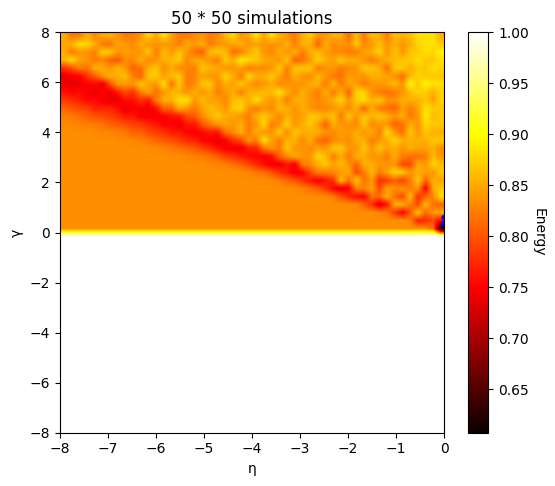

,network_index,gamma,eta,energy
0,0,0.60,0.0,0.632353
1,1,0.35,0.0,0.540663
2,2,0.35,0.0,0.750000
3,3,0.35,0.0,0.750000
4,4,0.35,0.0,0.808824


In [ ]:
#  Plot + overlay the white dots = each subject’s best-fit (eta, gamma)

title_part = f"{number_individual_gammas}_{number_individual_etas}"
plot_energy_landscape(etas, gammas, E, df_best=df_best,
                    title=f"{number_individual_etas} * {number_individual_gammas} simulations", savepath=OUTPUT_PATH + f"/figure4_like_heatmap_{title_part}.png")

# save the energy landscape data
energy_landscape_df = pd.DataFrame(E, columns=etas, index=gammas)
energy_landscape_df.index.name = 'gamma'
energy_landscape_df.columns.name = 'eta'
energy_landscape_df.to_csv(OUTPUT_PATH + f"/energy_landscape_{title_part}.csv")

df_best

In [58]:
print("Finished")

Finished


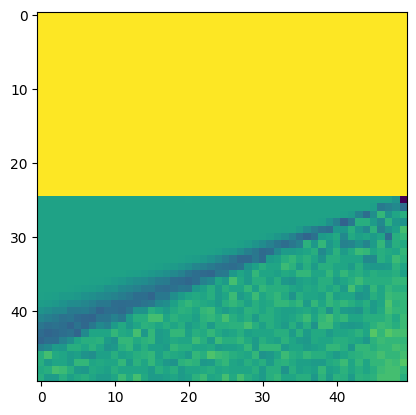

In [61]:
plt.imshow(E)

In [71]:
E[gammas < 0].shape

(25, 50)

In [69]:
gammas[gammas < 0]

array([-8.        , -7.67346939, -7.34693878, -7.02040816, -6.69387755,
       -6.36734694, -6.04081633, -5.71428571, -5.3877551 , -5.06122449,
       -4.73469388, -4.40816327, -4.08163265, -3.75510204, -3.42857143,
       -3.10204082, -2.7755102 , -2.44897959, -2.12244898, -1.79591837,
       -1.46938776, -1.14285714, -0.81632653, -0.48979592, -0.16326531])

(50, 50) (50,) (50,)
-8.0 0.0 -8.0 8.0


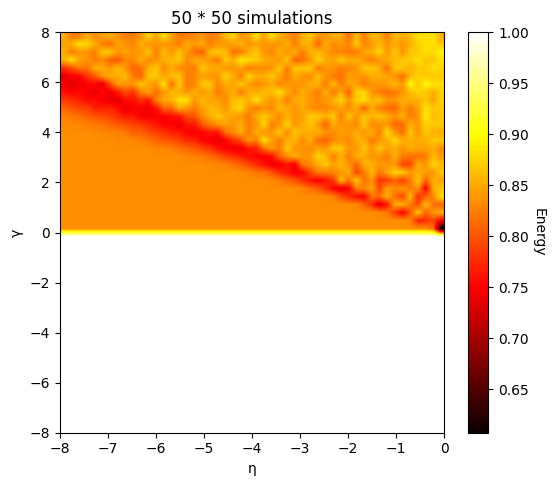

(<Figure size 620x520 with 2 Axes>,
 <Axes: title={'center': '50 * 50 simulations'}, xlabel='η', ylabel='γ'>)

In [84]:
def plot_energy_landscape_small(etas, gammas, energy_grid, df_best=None,
                          title="", # 10,000 simulations",
                          vmin=None, vmax=None, savepath=None, show=True):
    """
    Plot a Figure-4-style heatmap with optional white dots for best-fit models.
    """
    fig, ax = plt.subplots(figsize=(6.2, 5.2)) # , dpi=150)

    gammas_short = gammas #[gammas < 0]
    E_short = energy_grid #[gammas < 0] 
    print(E_short.shape, gammas_short.shape, etas.shape)
    print(etas.min(), etas.max(), gammas_short.min(), gammas_short.max())
    
    # Heatmap: black=low (good), yellow=high (bad) like Mousley; 'hot' does that.
    im = ax.imshow(E_short,
                   origin="lower",
                   extent=[etas.min(), etas.max(), gammas_short.min(), gammas_short.max()],
                   aspect="auto",
                   cmap="hot",
                   vmin=vmin, vmax=vmax,
                   interpolation="bilinear")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Energy", rotation=270, labelpad=12)

    # Axis labels/range
    ax.set_xlabel("η")
    ax.set_ylabel("γ")
    ax.set_title(title)

    # # Overlay best-fit points (one per subject)
    # if df_best is not None and {"eta","gamma"}.issubset(df_best.columns):
    #     ax.scatter(df_best["eta"].values, df_best["gamma"].values,
    #             #    s=8, c="white", edgecolors="none", alpha=0.95, zorder=3)
    #                s=16, c="blue", edgecolors="none", alpha=0.95, zorder=3)
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()
    return fig, ax

title_part = f"{number_individual_gammas}_{number_individual_etas}"
plot_energy_landscape_small(etas, gammas, E, df_best=df_best,
                    title=f"{number_individual_etas} * {number_individual_gammas} simulations")

In [ ]:
# scatter plot with graph descriptor parameters and a ESN parameter as the color. 

In [ ]:
# # save the energy landscape data
# energy_landscape_df = pd.DataFrame(E, columns=etas, index=gammas)
# energy_landscape_df.index.name = 'gamma'
# energy_landscape_df.columns.name = 'eta'
# energy_landscape_df.to_csv(OUTPUT_PATH + f"/energy_landscape_{title_part}.csv")

In [37]:
# import numpy as np
# from scipy import linalg
# from sklearn.linear_model import Ridge
# from sklearn.metrics import mean_squared_error

# class ESN:
#     def __init__(self, mask, in_dim, res_dim, rho=0.95, seed=None):
#         rng = np.random.RandomState(seed)
#         # Reservoir weight: random uniform, masked by empirical topology
#         W = rng.uniform(-1, 1, (res_dim, res_dim)) * mask
#         # Rescale to desired spectral radius
#         lam = np.max(np.abs(linalg.eigvals(W)))
#         W *= (rho / lam) if lam > 0 else 1.0
#         self.W, self.W_in = W, rng.uniform(-1, 1, (res_dim, in_dim + 1))
#         self.W_out = None

#     def _step(self, prev_state, u):
#         pre = self.W_in.dot(np.hstack([1, u])) + self.W.dot(prev_state)
#         return np.tanh(pre)

#     def fit(self, U, Y, washout=100, alpha=1e-6):
#         T = U.shape[0]
#         states = np.zeros((T, self.W.shape[0]))
#         x = np.zeros(self.W.shape[0])
#         for t in range(T):
#             x = self._step(x, U[t])
#             states[t] = x
#         # discard initial washout
#         S, Uw, Yw = states[washout:], U[washout:], Y[washout:]
#         X = np.hstack([np.ones((S.shape[0], 1)), Uw, S])
#         reg = Ridge(alpha=alpha, fit_intercept=False).fit(X, Yw)
#         self.W_out = reg.coef_
#         return self

#     def predict(self, U, washout=100):
#         T = U.shape[0]
#         states = np.zeros((T, self.W.shape[0]))
#         x = np.zeros(self.W.shape[0])
#         for t in range(T):
#             x = self._step(x, U[t])
#             states[t] = x
#         S, Uw = states[washout:], U[washout:]
#         X = np.hstack([np.ones((S.shape[0], 1)), Uw, S])
#         return X.dot(self.W_out.T)

# def evaluate(connectomes, U, Y, runs=1000, washout=100):
#     """
#     connectomes: np.ndarray of shape (N, N, M)
#     U: inputs array of shape (T, in_dim)
#     Y: targets array of shape (T, out_dim)
#     returns: np.ndarray of M×runs MSE values
#     """
#     N, _, M = connectomes.shape
#     perf = np.zeros((M, runs))
#     for s in range(M):
#         mask = (connectomes[:, :, s] != 0).astype(int)
#         for r in range(runs):
#             esn = ESN(mask, in_dim=U.shape[1], res_dim=N, rho=0.95, seed=r)
#             esn.fit(U, Y, washout=washout)
#             Ypred = esn.predict(U, washout=washout)
#             perf[s, r] = mean_squared_error(Y[washout:], Ypred)
#     return perf

# # if __name__ == "__main__":
#     # === Load your data ===
#     # connectomes = np.load("connectomes.npy")  # shape (N, N, M)
#     # U = np.load("inputs.npy")               # shape (T, in_dim)
#     # Y = np.load("targets.npy")              # shape (T, out_dim)

#     # Compute performance
#     # perf = evaluate(connectomes, U, Y, runs=1000, washout=100)
#     # np.save("esn_mse_results.npy", perf)
#     # print("Saved ESN MSE matrix with shape:", perf.shape)
#     pass


# ESNs

In [38]:
# import numpy as np, pandas as pd
# from reservoirpy.nodes import Reservoir, Ridge
# from reservoirpy.mat_gen import spectral_radius

# def mask_to_W(mask, rng, rho=0.9):
#     M = (mask != 0).astype(float)
#     W = rng.uniform(-1, 1, size=M.shape) * M
#     np.fill_diagonal(W, 0.0)
#     return spectral_radius(W, sr=rho)  # rescale to target spectral radius

# def narma10_dataset(trials=1000, T=1200, seed=0):
#     rng = np.random.default_rng(seed); data=[]
#     for _ in range(trials):
#         u = rng.uniform(0, .5, size=T).reshape(-1,1)
#         y = np.zeros((T,1))
#         for t in range(10, T):
#             y[t] = 0.3*y[t-1] + 0.05*y[t-1]*y[t-10:t].sum() + 1.5*u[t-10]*u[t-1] + 0.1
#         data.append((u, y))
#     return data

# def eval_subject(mask, trials=1000, rho=0.9, washout=200, seed=0):
#     rng = np.random.default_rng(seed)
#     W = mask_to_W(mask, rng, rho=rho)
#     res = Reservoir(W.shape[0], W=W, sr=None, lr=1.0)   # use our W; no re-init
#     readout = Ridge(ridge=1e-6)
#     esn = res >> readout

#     ds = narma10_dataset(trials=trials, seed=seed)
#     mses=[]
#     for U, Y in ds:
#         esn = esn.fit(U[:washout], Y[:washout])  # warmup to init states
#         yhat = esn.run(U[washout:], reset=False)
#         mse = ((Y[washout:]-yhat)**2).mean()
#         mses.append(float(mse))
#     return np.mean(mses), np.std(mses)

# # connectomes: (N, N, M)
# A = all_connectomes
# rows=[]
# for m in range(A.shape[2]):
#     np.fill_diagonal(A[:, :, m], 0)
#     mean_mse, std_mse = eval_subject(A[:, :, m], trials=1, rho=0.9, washout=200, seed=123+m)
#     rows.append({"subject": m, "mean_mse": mean_mse, "std_mse": std_mse})
#     break
# print(pd.DataFrame(rows))


In [39]:
# import numpy as np
# import pandas as pd
# from sklearn.linear_model import Ridge
# from sklearn.metrics import mean_squared_error, r2_score


# def make_narma10(u, a=0.3, b=0.05, c=1.5, d=0.1):
#     """
#     Generate NARMA10 target for input u (shape: [T]).
#     Returns y (shape: [T]) with standard warmup.
#     """
#     T = len(u)
#     y = np.zeros(T)
#     for t in range(10, T):
#         y[t] = (a * y[t-1]
#                 + b * y[t-1] * np.sum(y[t-10:t])
#                 + c * u[t-10] * u[t-1]
#                 + d)
#     return y

# def make_narma10_dataset(n_trials=1000, T=1200, seed=0):
#     """
#     Build synthetic dataset: 1D input, 1D output (NARMA10).
#     Returns list of (U, Y) pairs; each U is [T, 1], Y is [T, 1].
#     """
#     rng = np.random.default_rng(seed)
#     data = []
#     for _ in range(n_trials):
#         u = rng.uniform(0, 0.5, size=T)  # classic NARMA10 input
#         y = make_narma10(u)
#         data.append((u.reshape(-1, 1), y.reshape(-1, 1)))
#     return data


In [40]:



# # ---------------------------
# # ESN core (NumPy)
# # ---------------------------

# def rescale_spectral_radius(W, rho_target=0.9, eps=1e-12):
#     # Power iteration for largest eigenvalue magnitude
#     v = np.random.default_rng().normal(size=(W.shape[0], 1))
#     v /= np.linalg.norm(v) + eps
#     for _ in range(100):
#         v = W @ v
#         n = np.linalg.norm(v) + eps
#         v /= n
#     # Rayleigh quotient approximation of spectral radius
#     lam = float(np.linalg.norm(W @ v) / (np.linalg.norm(v) + eps))
#     if lam < eps:
#         return W  # already near zero
#     return (rho_target / lam) * W

# def init_reservoir_from_connectome(mask, weight_scale=1.0, rho=0.9, rng=None, keep_self_loops=False):
#     """
#     mask: (N, N) binary or weighted >0 indicates a connection i->j.
#     Randomizes weights on those edges in [-1,1], zeros elsewhere, rescales to spectral radius rho.
#     """
#     rng = np.random.default_rng() if rng is None else rng
#     M = (mask != 0).astype(float)
#     # Random signs/weights on existing edges
#     W = rng.uniform(-1.0, 1.0, size=M.shape) * M * weight_scale
#     if not keep_self_loops:
#         np.fill_diagonal(W, 0.0)
#     # Spectral radius normalization
#     W = rescale_spectral_radius(W, rho_target=rho)
#     return W

# def run_esn_trial(W, U, Y, ridge=1e-6, leak=1.0, washout=200, input_scale=1.0, bias_scale=0.0, rng=None):
#     """
#     W: (N, N) reservoir
#     U: (T, input_dim)
#     Y: (T, output_dim)
#     Returns dict with metrics and optionally the trained readout.
#     """
#     rng = np.random.default_rng() if rng is None else rng
#     N = W.shape[0]
#     T, input_dim = U.shape
#     out_dim = Y.shape[1]

#     # Input matrix Win and bias
#     Win = rng.uniform(-1, 1, size=(N, input_dim)) * input_scale
#     b = rng.uniform(-1, 1, size=(N,)) * bias_scale

#     # Run reservoir
#     X = np.zeros((T, N))
#     x = np.zeros(N)
#     for t in range(T):
#         pre = Win @ U[t] + W @ x + b
#         x_new = np.tanh(pre)
#         x = (1 - leak) * x + leak * x_new  # leaky integration
#         X[t] = x

#     # Train readout on post-washout states
#     Xtr = X[washout:]
#     Ytr = Y[washout:]

#     # Add bias term in readout (column of ones)
#     Xtr_aug = np.hstack([Xtr, np.ones((Xtr.shape[0], 1))])
#     reg = Ridge(alpha=ridge, fit_intercept=False)
#     reg.fit(Xtr_aug, Ytr)

#     # Evaluate on the same sequence (can split if you have separate val/test)
#     Yhat = reg.predict(Xtr_aug)
#     mse = float(mean_squared_error(Ytr, Yhat))
#     r2 = float(r2_score(Ytr, Yhat))

#     return {"mse": mse, "r2": r2, "readout": reg, "states": X}


# # ---------------------------
# # Batch runner
# # ---------------------------

# def evaluate_connectome_esn_set(connectomes, trials=1000, task="narma10",
#                                 seq_len=1200, washout=200, rho=0.9, ridge=1e-6,
#                                 leak=1.0, input_scale=1.0, bias_scale=0.0, seed=42,
#                                 user_dataset=None):
#     """
#     connectomes: np.ndarray of shape (N, N, M)
#     task: "narma10" or "custom"
#     user_dataset: list of (U, Y) pairs if task="custom"
#                   U: [T, input_dim], Y: [T, output_dim]
#     Returns: (df_subject_metrics, df_overall)
#     """
#     rng = np.random.default_rng(seed)
#     N, N2, M = connectomes.shape
#     assert N == N2, "Connectomes must be (N, N, M)."

#     # Build dataset
#     if task == "narma10":
#         dataset = make_narma10_dataset(n_trials=trials, T=seq_len, seed=seed)
#     elif task == "custom":
#         assert user_dataset is not None and len(user_dataset) >= trials, \
#             "Provide user_dataset = [(U, Y), ...] with at least `trials` items."
#         dataset = user_dataset[:trials]
#     else:
#         raise ValueError("Unknown task")

#     records = []

#     for m in range(M):
#         mask = connectomes[:, :, m]
#         # Use connectome as topology mask
#         W = init_reservoir_from_connectome(mask, rho=rho, rng=rng)

#         subj_mses, subj_r2s = [], []
#         for trial_idx in range(trials):
#             U, Y = dataset[trial_idx]
#             # Safety: ensure 2D
#             U = np.atleast_2d(U)
#             Y = np.atleast_2d(Y)
#             res = run_esn_trial(
#                 W, U, Y,
#                 ridge=ridge, leak=leak, washout=washout,
#                 input_scale=input_scale, bias_scale=bias_scale,
#                 rng=rng
#             )
#             subj_mses.append(res["mse"])
#             subj_r2s.append(res["r2"])

#         records.append({
#             "subject_index": m,
#             "mean_mse": float(np.mean(subj_mses)),
#             "std_mse": float(np.std(subj_mses)),
#             "mean_r2": float(np.mean(subj_r2s)),
#             "std_r2": float(np.std(subj_r2s)),
#             "n_trials": trials
#         })

#     df_subjects = pd.DataFrame(records)
#     df_overall = pd.DataFrame({
#         "overall_mean_mse": [df_subjects["mean_mse"].mean()],
#         "overall_std_mse": [df_subjects["mean_mse"].std()],
#         "overall_mean_r2": [df_subjects["mean_r2"].mean()],
#         "overall_std_r2": [df_subjects["mean_r2"].std()],
#         "subjects": [M],
#         "trials_per_subject": [trials]
#     })

#     return df_subjects, df_overall


# # ---------------------------
# # Example usage (edit me)
# # ---------------------------
# # if __name__ == "__main__":
#     # Example: fabricate a small connectome set (replace with your real data)
#     # N, M = 90, 5
#     # rng = np.random.default_rng(0)
#     # connectomes = (rng.random((N, N, M)) < 0.05).astype(float)  # 5% density mask
# for m in range(all_connectomes.shape[2]):
#     np.fill_diagonal(all_connectomes[:, :, m], 0)

# # Evaluate on NARMA10 with 1000 trials/subject
# df_subj, df_all = evaluate_connectome_esn_set(
#     all_connectomes,
#     trials=1000,
#     task="narma10",
#     seq_len=1200,
#     washout=200,
#     rho=0.9,
#     ridge=1e-6,
#     leak=1.0,
#     input_scale=1.0,
#     bias_scale=0.0,
#     seed=123
# )

# print(df_subj.head())
# print(df_all)


In [41]:
# """
# =========================================================
# ESNRegressor example
# =========================================================

# This example shows a minimal example of Echo State Network
# applied to a regression problem.
# """
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.metrics import r2_score
# from sklearn.model_selection import train_test_split

# from echoes import ESNRegressor
# from echoes.plotting import set_mystyle

# set_mystyle()  # optional: set aesthetics


# # Prepare synthetic data 
# x = np.linspace(0, 30*np.pi, 1000).reshape(-1,1)
# inputs = np.sin(x) + np.random.normal(scale=.1, size=x.shape)
# outputs = np.cos(x) + np.random.normal(scale=.1, size=x.shape)
# # x.shape, inputs.shape, outputs.shape # x.shape, inputs.shape, outputs.shape

# X_train, X_test, y_train, y_test = train_test_split(inputs, outputs, test_size=.3, shuffle=False)

# esn = ESNRegressor(
#     spectral_radius=.95,
#     leak_rate=.4,
#     n_transient=100,    
#     regression_method="pinv",
#     random_state=42
# )
# esn.fit(X_train, y_train)

# print("training r2 score: ", esn.score(X_train, y_train))
# print("test r2 score: ", esn.score(X_test, y_test))

# # Get prediction for plotting
# y_pred = esn.predict(X_test)

# plt.figure(figsize=(15, 4))
# plt.subplot(1, 3, (1, 2))
# plt.plot(y_test[esn.n_transient:], label='target signal',
#          color="steelblue", linewidth=5.5)
# plt.plot(y_pred[esn.n_transient:], label='predicted signal',
#          linestyle='--', color="orange",  linewidth=2,)
# plt.ylabel("oscillator")
# plt.xlabel('time')
# plt.legend(fontsize=("small"), loc=2)

# plt.subplot(1, 3, 3)
# plt.title(r"$W^{out}$ weights distribution")
# plt.xlabel('weight')
# plt.ylabel('frequency')
# plt.hist(esn.W_out_.flat)